   PARAMÈTRES CLÉS DE L'ÉOLIENNE
  Vitesse de démarrage (cut-in)   : 4.5  m/s
  Vitesse d'écrêtage  (rated)     : 15.5  m/s
  Vitesse d'arrêt     (cut-out)   : 25.5  m/s
  Puissance maximale              : 1436.8  kW
  Rendement η                     : 0.3966  ±  0.0001
  Coefficient de puissance Cp     : 0.2350
  (Cp = η × 16/27,  Betz max = 0.5926)


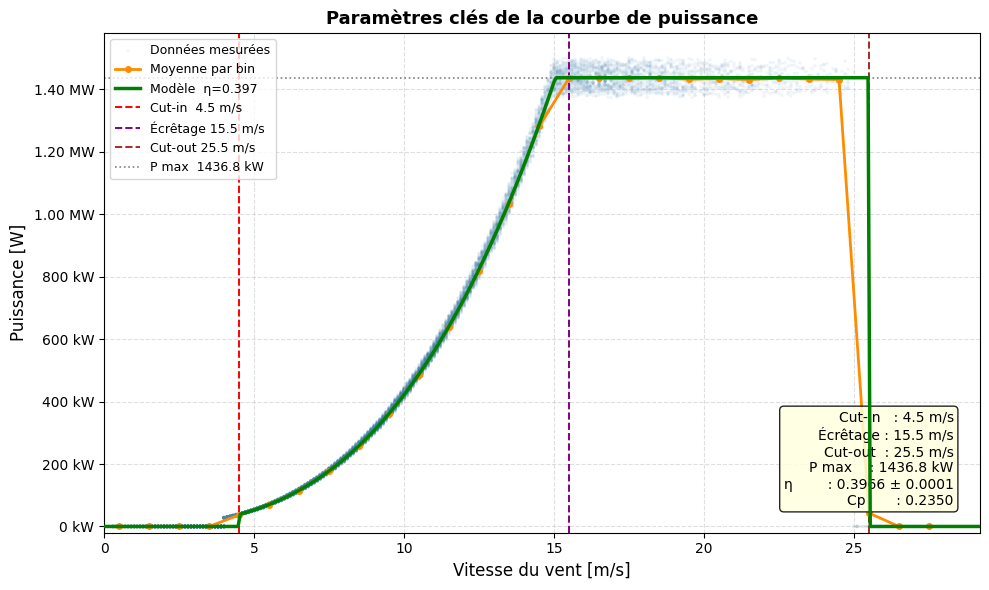

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic
from scipy.optimize import curve_fit

# --- Chargement des données ---
df = pd.read_csv('donnees.txt', sep='\t', skipinitialspace=True)
df.columns = df.columns.str.strip()
df = df[df['Statut'] == 1].copy()

vitesse   = df['Vitess_Vent_[m/s]'].values
puissance = df['Pelec[w]'].values
patm      = df['Patm[Pa]'].values
temp      = df['Temp[degC]'].values + 273.15

# --- Paramètres fixes ---
D     = 60.0
R_air = 287.0
A     = np.pi * D**2 / 4
rho_moy = np.mean(patm / (R_air * temp))

# ---------------------------------------------------------------
# 1. Moyenne binée pour avoir une courbe propre
# ---------------------------------------------------------------
bins = np.arange(0, vitesse.max() + 2, 1)
mean_p, bin_edges, _ = binned_statistic(vitesse, puissance,
                                        statistic='mean', bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
valid = ~np.isnan(mean_p)
v_bin = bin_centers[valid]
p_bin = mean_p[valid]

# ---------------------------------------------------------------
# 2. Vitesse minimale de démarrage (cut-in)
#    = premier bin où la puissance moyenne devient franchement positive
# ---------------------------------------------------------------
SEUIL_DEMARRAGE = 0.01 * np.nanmax(mean_p)   # 1 % de la puissance max
idx_cutin = np.argmax(p_bin > SEUIL_DEMARRAGE)
v_cutin = v_bin[idx_cutin]

# ---------------------------------------------------------------
# 3. Puissance maximale et vitesse d'écrêtage (rated speed)
#    = première vitesse à laquelle la puissance atteint son plateau max
# ---------------------------------------------------------------
p_max = np.nanmax(p_bin)
SEUIL_RATED = 0.98 * p_max                   # 98 % du max = plateau
idx_rated = np.argmax(p_bin >= SEUIL_RATED)
v_rated = v_bin[idx_rated]                   # vitesse d'écrêtage

# ---------------------------------------------------------------
# 4. Deuxième vitesse limite (cut-out)
#    = dernière vitesse bin où la puissance repasse au-dessus du seuil
#      de démarrage avant de redescendre définitivement à 0
# ---------------------------------------------------------------
above = p_bin > SEUIL_DEMARRAGE
# on cherche le dernier True consécutif depuis la fin
idx_cutout_last = len(above) - 1 - np.argmax(above[::-1])
v_cutout = v_bin[idx_cutout_last]

# ---------------------------------------------------------------
# 5. Rendement η via régression sur la zone [v_cutin ; v_rated]
# ---------------------------------------------------------------
mask_reg = (vitesse >= v_cutin) & (vitesse <= v_rated)

def modele(V, eta):
    return eta * (16/27) * 0.5 * rho_moy * A * V**3

popt, pcov = curve_fit(modele, vitesse[mask_reg], puissance[mask_reg],
                       p0=[0.20], bounds=(0.0, 0.6))
eta_opt = popt[0]
eta_std  = np.sqrt(pcov[0][0])
Cp = eta_opt * 16/27

# ---------------------------------------------------------------
# Affichage console
# ---------------------------------------------------------------
sep = "=" * 50
print(sep)
print("   PARAMÈTRES CLÉS DE L'ÉOLIENNE")
print(sep)
print(f"  Vitesse de démarrage (cut-in)   : {v_cutin:.1f}  m/s")
print(f"  Vitesse d'écrêtage  (rated)     : {v_rated:.1f}  m/s")
print(f"  Vitesse d'arrêt     (cut-out)   : {v_cutout:.1f}  m/s")
print(f"  Puissance maximale              : {p_max/1e3:.1f}  kW")
print(f"  Rendement η                     : {eta_opt:.4f}  ±  {eta_std:.4f}")
print(f"  Coefficient de puissance Cp     : {Cp:.4f}")
print(f"  (Cp = η × 16/27,  Betz max = {16/27:.4f})")
print(sep)

# ---------------------------------------------------------------
# Visualisation
# ---------------------------------------------------------------
k_opt = eta_opt * (16/27) * 0.5 * rho_moy * A
v_fit = np.linspace(0, vitesse.max() + 2, 400)
p_fit = np.where(
    v_fit < v_cutin, 0,
    np.where(v_fit <= v_cutout,
             np.minimum(k_opt * v_fit**3, p_max),
             0)
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(vitesse, puissance, color='steelblue', alpha=0.08,
           edgecolors='none', s=6, label='Données mesurées', zorder=1)
ax.plot(v_bin, p_bin, 'o-', color='darkorange', linewidth=2,
        markersize=4, label='Moyenne par bin', zorder=3)
ax.plot(v_fit, p_fit, '-', color='green', linewidth=2.5,
        label=f'Modèle  η={eta_opt:.3f}', zorder=4)

# Annotations des paramètres clés
ymax = p_max * 1.1
ax.axvline(v_cutin,  color='red',    linestyle='--', linewidth=1.4,
           label=f'Cut-in  {v_cutin:.1f} m/s')
ax.axvline(v_rated,  color='purple', linestyle='--', linewidth=1.4,
           label=f'Écrêtage {v_rated:.1f} m/s')
ax.axvline(v_cutout, color='brown',  linestyle='--', linewidth=1.4,
           label=f'Cut-out {v_cutout:.1f} m/s')
ax.axhline(p_max,    color='gray',   linestyle=':',  linewidth=1.2,
           label=f'P max  {p_max/1e3:.1f} kW')

textstr = (
    f"Cut-in   : {v_cutin:.1f} m/s\n"
    f"Écrêtage : {v_rated:.1f} m/s\n"
    f"Cut-out  : {v_cutout:.1f} m/s\n"
    f"P max    : {p_max/1e3:.1f} kW\n"
    f"η        : {eta_opt:.4f} ± {eta_std:.4f}\n"
    f"Cp       : {Cp:.4f}"
)
ax.text(0.97, 0.05, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))

ax.set_xlabel('Vitesse du vent [m/s]', fontsize=12)
ax.set_ylabel('Puissance [W]', fontsize=12)
ax.set_title('Paramètres clés de la courbe de puissance', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim(0, vitesse.max() + 2)
ax.set_ylim(-20000, ymax)
ax.yaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, _: f'{x/1e6:.2f} MW' if x >= 1e6 else f'{x/1e3:.0f} kW'))

plt.tight_layout()
plt.savefig('parametres_eolienne.png', dpi=150, bbox_inches='tight')
plt.show()


In [2]:
# ---------------------------------------------------------------
# >>> MODIFIEZ CETTE VALEUR <
# ---------------------------------------------------------------
V_VENT = 12.0   # vitesse du vent en m/s
# ---------------------------------------------------------------

# --- Prédiction ---
if V_VENT < 0:
    zone              = "vitesse invalide"
    puissance_predite = None
elif V_VENT < v_cutin:
    zone              = f"arrêt — en dessous du cut-in ({v_cutin:.1f} m/s)"
    puissance_predite = 0.0
elif V_VENT <= v_rated:
    zone              = "production variable (modèle Betz)"
    puissance_predite = k_opt * V_VENT**3
elif V_VENT <= v_cutout:
    zone              = "écrêtage — puissance maximale"
    puissance_predite = p_max
else:
    zone              = f"arrêt de sécurité — au-dessus du cut-out ({v_cutout:.1f} m/s)"
    puissance_predite = 0.0

# --- Résultat ---
print("=" * 45)
print("  PRÉDICTION DE PUISSANCE")
print("=" * 45)
if puissance_predite is not None:
    print(f"  Vitesse entrée : {V_VENT:.2f} m/s")
    print(f"  Puissance      : {puissance_predite/1e3:.2f} kW")
    print(f"  Zone           : {zone}")
else:
    print(f"  Erreur         : {zone}")
print("=" * 45)


  PRÉDICTION DE PUISSANCE
  Vitesse entrée : 12.00 m/s
  Puissance      : 729.06 kW
  Zone           : production variable (modèle Betz)
